In [1]:
# Cell 1 — Imports + load
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
# Cell 2 — Shape and data types
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)

Shape: (119390, 32)

Data types:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
a

Cancellation rate:
is_canceled
Not cancelled    0.629584
Cancelled        0.370416
Name: proportion, dtype: float64


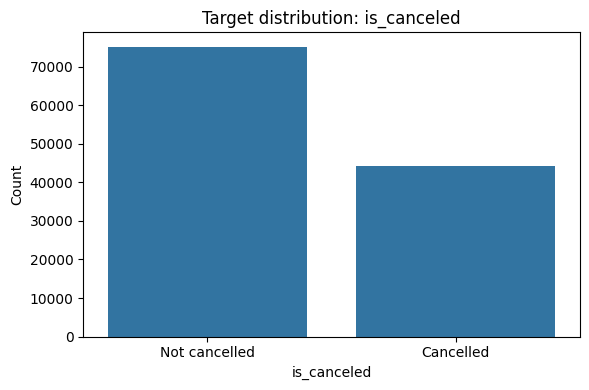

In [3]:
# Cell 3 — Target distribution (is_canceled)
print('Cancellation rate:')
print(
    df['is_canceled']
    .value_counts(normalize=True)
    .rename({0: 'Not cancelled', 1: 'Cancelled'})
)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='is_canceled')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not cancelled', 'Cancelled'])
plt.title('Target distribution: is_canceled')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — Missingness check
missing = df.isna().sum().sort_values(ascending=False)
print('Columns with missing values:')
print(missing[missing > 0])

Columns with missing values:
company     112593
agent        16340
country        488
children         4
dtype: int64
